In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import timedelta
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("All imports done")

2026-03-21 06:08:27.357381: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774073307.768622      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774073307.882379      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774073308.871634      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774073308.871677      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774073308.871680      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
All imports done


In [4]:
start_load = time.time()

interaction_data  = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv')
presentations     = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv')
presentations_df  = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv')
ratings_matrix    = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv')
recommendations   = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv')
user_profiles     = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv')

print(f"Loaded in {time.time()-start_load:.2f}s")
print(f"interaction_data : {interaction_data.shape}")
print(f"ratings_matrix   : {ratings_matrix.shape}")
print(f"recommendations  : {recommendations.shape}")
print(f"user_profiles    : {user_profiles.shape}")
print(f"presentations    : {presentations.shape}")

Loaded in 0.27s
interaction_data : (25000, 75)
ratings_matrix   : (3000, 5)
recommendations  : (100, 26)
user_profiles    : (30, 5)
presentations    : (78, 15)


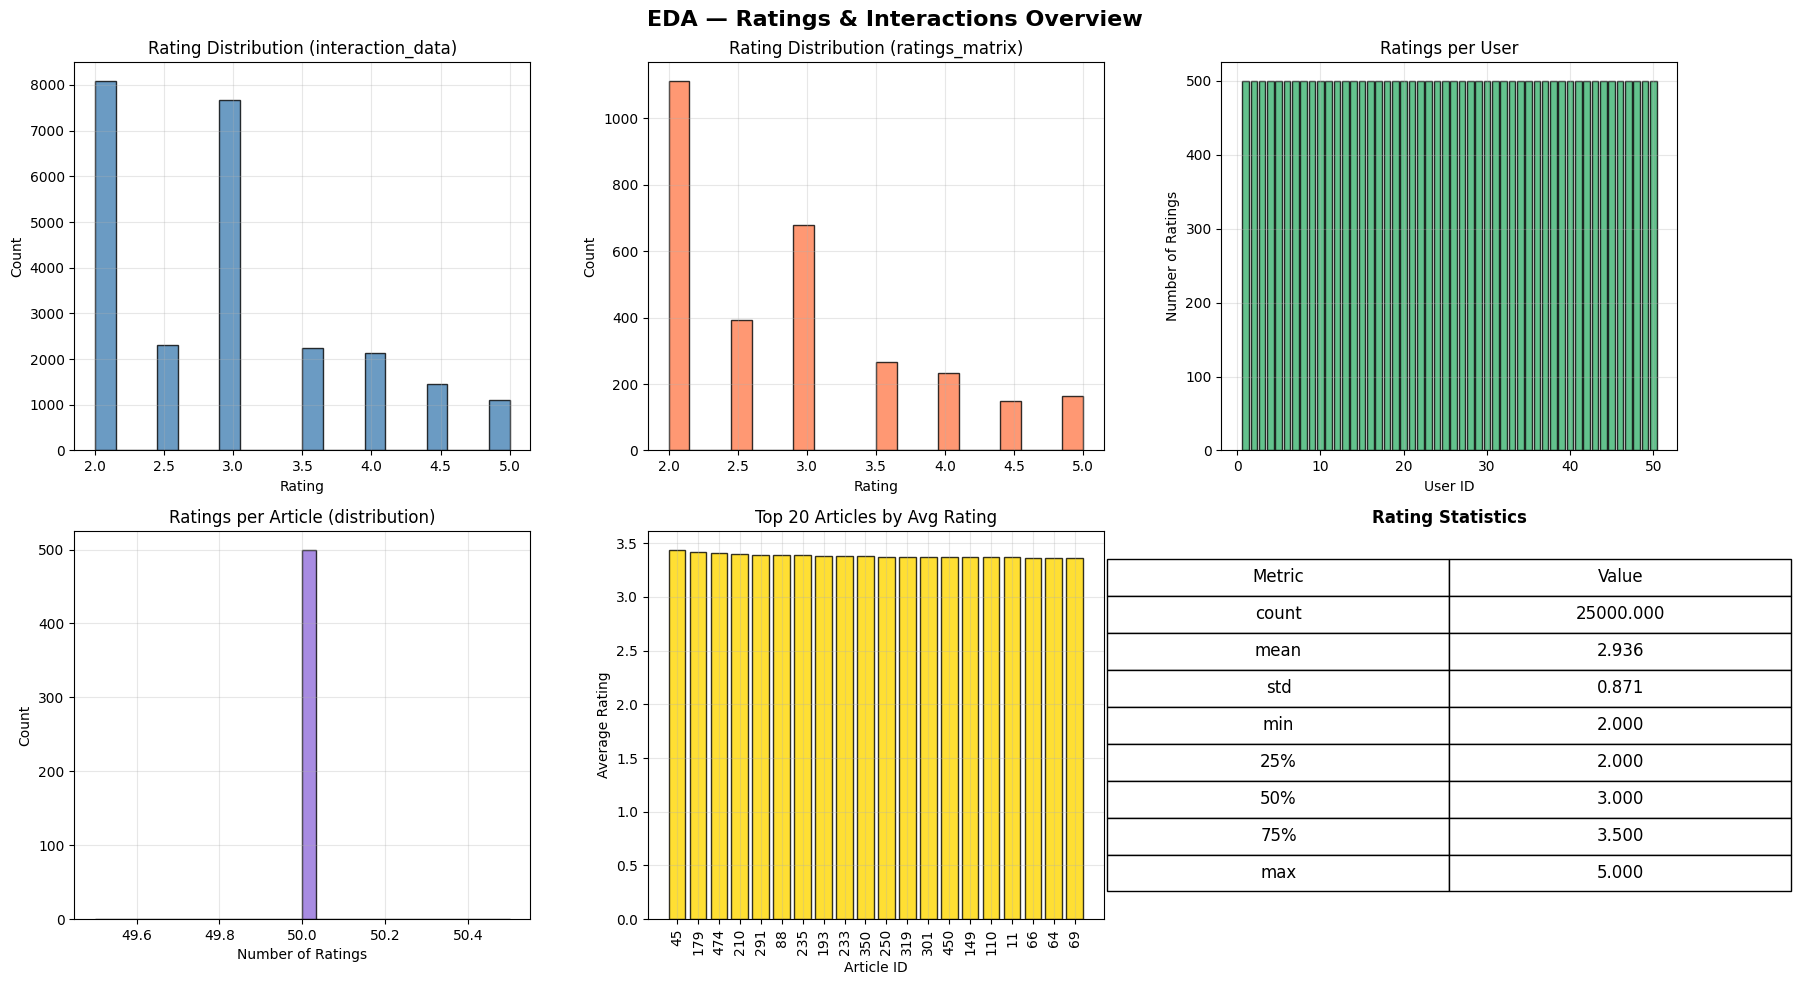


Unique users    : 50
Unique articles : 500
Total ratings   : 25000
Rating range    : 2.0 → 5.0
Sparsity        : 0.0000


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Ratings & Interactions Overview', fontsize=16, fontweight='bold')

# 1. Rating distribution — interaction_data
axes[0,0].hist(interaction_data['rating'], bins=20,
               color='steelblue', edgecolor='black', alpha=0.8)
axes[0,0].set_title('Rating Distribution (interaction_data)')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')
axes[0,0].grid(True, alpha=0.3)

# 2. Rating distribution — ratings_matrix
axes[0,1].hist(ratings_matrix['rating'], bins=20,
               color='coral', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Rating Distribution (ratings_matrix)')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('Count')
axes[0,1].grid(True, alpha=0.3)

# 3. Ratings per user
ratings_per_user = interaction_data.groupby('user_id')['rating'].count()
axes[0,2].bar(ratings_per_user.index, ratings_per_user.values,
              color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[0,2].set_title('Ratings per User')
axes[0,2].set_xlabel('User ID')
axes[0,2].set_ylabel('Number of Ratings')
axes[0,2].grid(True, alpha=0.3)

# 4. Ratings per article
ratings_per_article = interaction_data.groupby('article_id')['rating'].count()
axes[1,0].hist(ratings_per_article.values, bins=30,
               color='mediumpurple', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Ratings per Article (distribution)')
axes[1,0].set_xlabel('Number of Ratings')
axes[1,0].set_ylabel('Count')
axes[1,0].grid(True, alpha=0.3)

# 5. Average rating per article (top 20)
avg_per_article = interaction_data.groupby('article_id')['rating'].mean().sort_values(ascending=False).head(20)
axes[1,1].bar(avg_per_article.index.astype(str), avg_per_article.values,
              color='gold', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Top 20 Articles by Avg Rating')
axes[1,1].set_xlabel('Article ID')
axes[1,1].set_ylabel('Average Rating')
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].grid(True, alpha=0.3)

# 6. Rating stats summary
stats = interaction_data['rating'].describe()
axes[1,2].axis('off')
table_data = [[k, f"{v:.3f}"] for k, v in stats.items()]
table = axes[1,2].table(cellText=table_data,
                         colLabels=['Metric', 'Value'],
                         loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2)
axes[1,2].set_title('Rating Statistics', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nUnique users    : {interaction_data['user_id'].nunique()}")
print(f"Unique articles : {interaction_data['article_id'].nunique()}")
print(f"Total ratings   : {len(interaction_data)}")
print(f"Rating range    : {interaction_data['rating'].min()} → {interaction_data['rating'].max()}")
print(f"Sparsity        : {1 - len(ratings_matrix)/(ratings_matrix['user_id'].nunique()*ratings_matrix['article_id'].nunique()):.4f}")

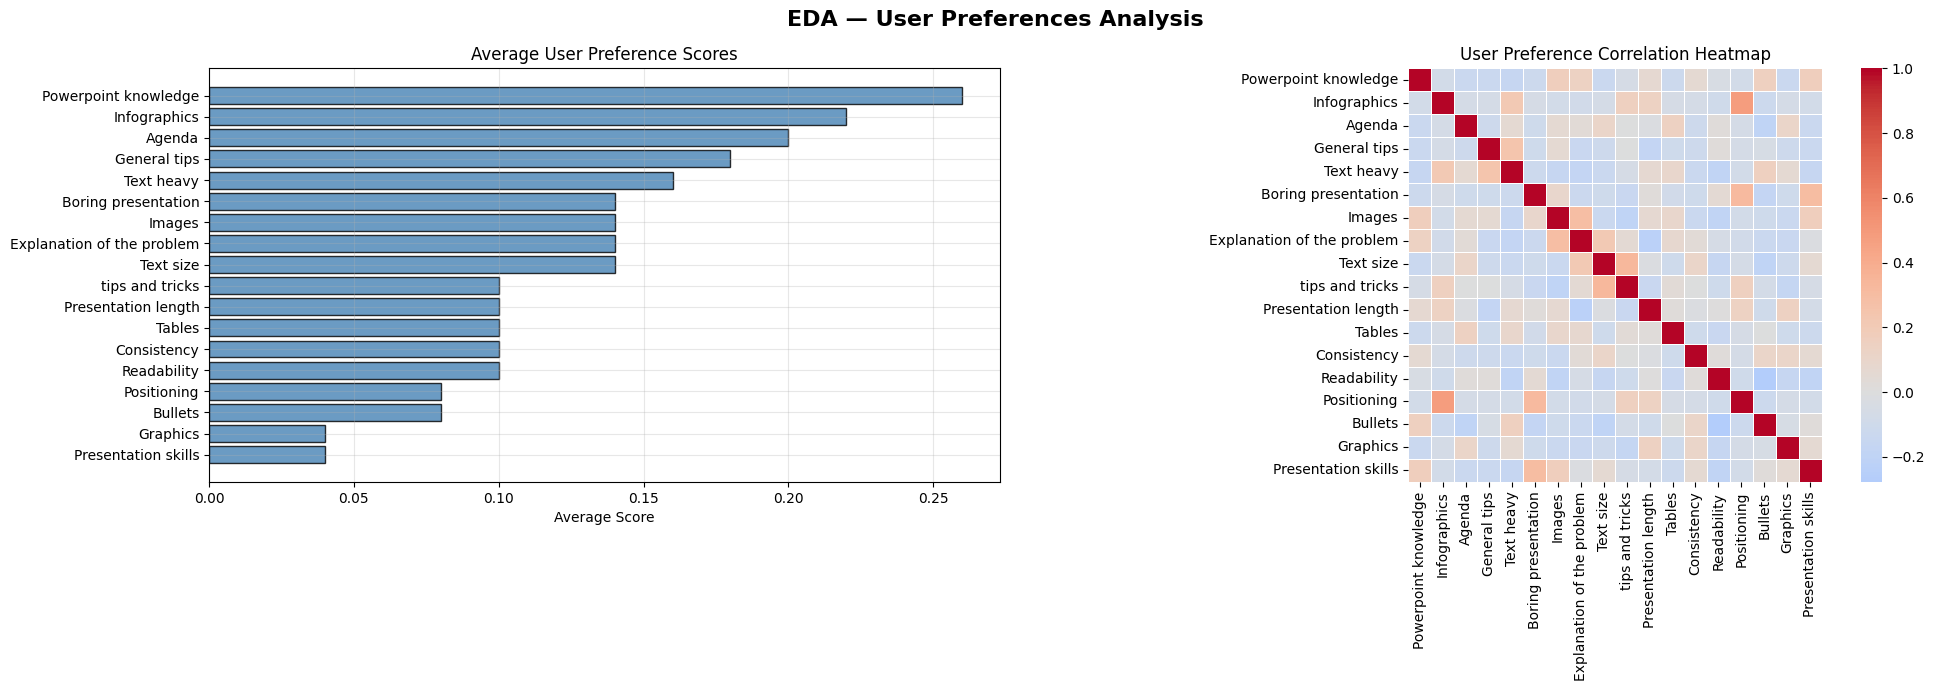

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# User preference columns
pref_cols = [c for c in interaction_data.columns if c.startswith('user_preference_')]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('EDA — User Preferences Analysis', fontsize=16, fontweight='bold')

# ---- 1. Average preference scores ----
avg_prefs = interaction_data[pref_cols].mean().sort_values(ascending=False)
clean_labels = [c.replace('user_preference_', '') for c in avg_prefs.index]

axes[0].barh(clean_labels, avg_prefs.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Average User Preference Scores')
axes[0].set_xlabel('Average Score')
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis()

# ---- 2. FULL Correlation heatmap (no masking) ----
pref_corr = interaction_data[pref_cols].corr()

sns.heatmap(pref_corr,
            ax=axes[1],
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            xticklabels=clean_labels,
            yticklabels=clean_labels,
            annot=False)

axes[1].set_title('User Preference Correlation Heatmap')
axes[1].tick_params(axis='x', rotation=90)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [11]:
# Check if you already have a merged dataframe
# Based on your EDA output, your merged df has 83 columns
# Let's recreate it properly

df_merged = interaction_data.copy()

# Merge user_profiles
df_merged = df_merged.merge(
    user_profiles[['user_id', 'type', 'location',
                   'preferences', 'preferred_presentation_type']],
    on='user_id',
    how='left',
    suffixes=('', '_user')
)

# Merge recommendations (article-level info)
df_merged = df_merged.merge(
    recommendations[['article_id', 'presentation_type',
                      'audience_type', 'Main issue', 'popularity']],
    on='article_id',
    how='left',
    suffixes=('', '_rec')
)

print(f"Merged shape: {df_merged.shape}")
print(f"\nConfirm columns exist:")
print(f"  preferred_presentation_type : {'preferred_presentation_type' in df_merged.columns}")
print(f"  audience_type               : {'audience_type' in df_merged.columns}")
print(f"  presentation_type           : {'presentation_type' in df_merged.columns}")

Merged shape: (25000, 83)

Confirm columns exist:
  preferred_presentation_type : True
  audience_type               : True
  presentation_type           : True


=== CHECKING DATAFRAMES ===

interaction_data shape  : (25000, 75)
user_profiles shape     : (30, 5)
recommendations shape   : (100, 26)

df_merged shape         : (25000, 83)
df_merged columns       : ['user_id', 'article_id', 'rating', 'timestamp', 'location', 'user_preference_Boring presentation', 'user_preference_Graphics', 'user_preference_Readability', 'user_preference_Consistency', 'user_preference_Images', 'user_preference_Bullets', 'user_preference_Text size', 'user_preference_Text heavy', 'user_preference_Tables', 'user_preference_Agenda', 'user_preference_Infographics', 'user_preference_Positioning', 'user_preference_Presentation length', 'user_preference_General tips', 'user_preference_Presentation skills', 'user_preference_Powerpoint knowledge', 'user_preference_tips and tricks', 'user_preference_Explanation of the problem', 'user_type_business', 'user_type_teacher', 'user_type_student', 'user_type_researcher', 'user_type_manager', 'user_type_technical', 'user_type_special

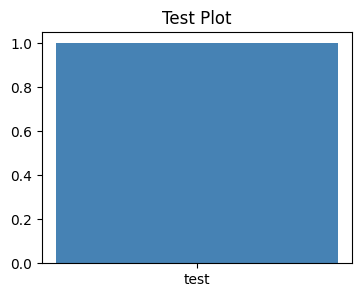


If you see a bar chart above, matplotlib is working fine


In [12]:
# ── DIAGNOSTIC: Run this and paste the output ─────────────

print("=== CHECKING DATAFRAMES ===")
print(f"\ninteraction_data shape  : {interaction_data.shape}")
print(f"user_profiles shape     : {user_profiles.shape}")
print(f"recommendations shape   : {recommendations.shape}")

# Check if df_merged exists
try:
    print(f"\ndf_merged shape         : {df_merged.shape}")
    print(f"df_merged columns       : {df_merged.columns.tolist()}")
except NameError:
    print("\ndf_merged does NOT exist — you skipped the Fix cell")

# Check what columns interaction_data actually has
print("\n=== INTERACTION_DATA COLUMNS ===")
for col in interaction_data.columns.tolist():
    print(f"  {col}")

# Check user_profiles columns
print("\n=== USER_PROFILES COLUMNS ===")
for col in user_profiles.columns.tolist():
    print(f"  {col}")

# Check recommendations columns
print("\n=== RECOMMENDATIONS COLUMNS ===")
for col in recommendations.columns.tolist():
    print(f"  {col}")

# Check if matplotlib is working at all
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.bar(['test'], [1], color='steelblue')
ax.set_title('Test Plot')
plt.show()
print("\nIf you see a bar chart above, matplotlib is working fine")

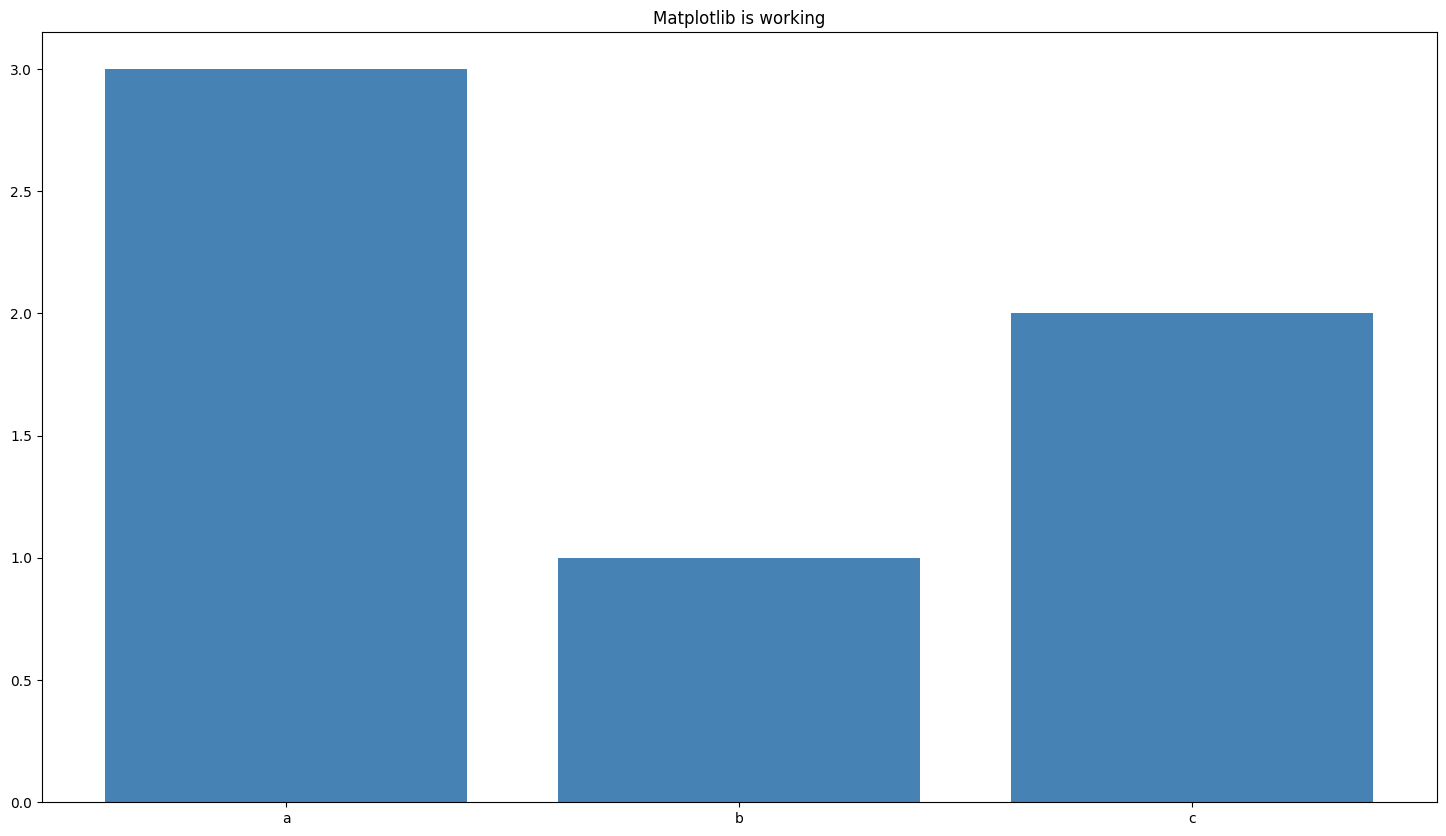

If you see the bar chart, you are good to go


In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (18, 10)
matplotlib.rcParams['figure.dpi']     = 100

# Quick test
fig, ax = plt.subplots()
ax.bar(['a','b','c'], [3,1,2], color='steelblue')
ax.set_title('Matplotlib is working')
plt.show()
print("If you see the bar chart, you are good to go")

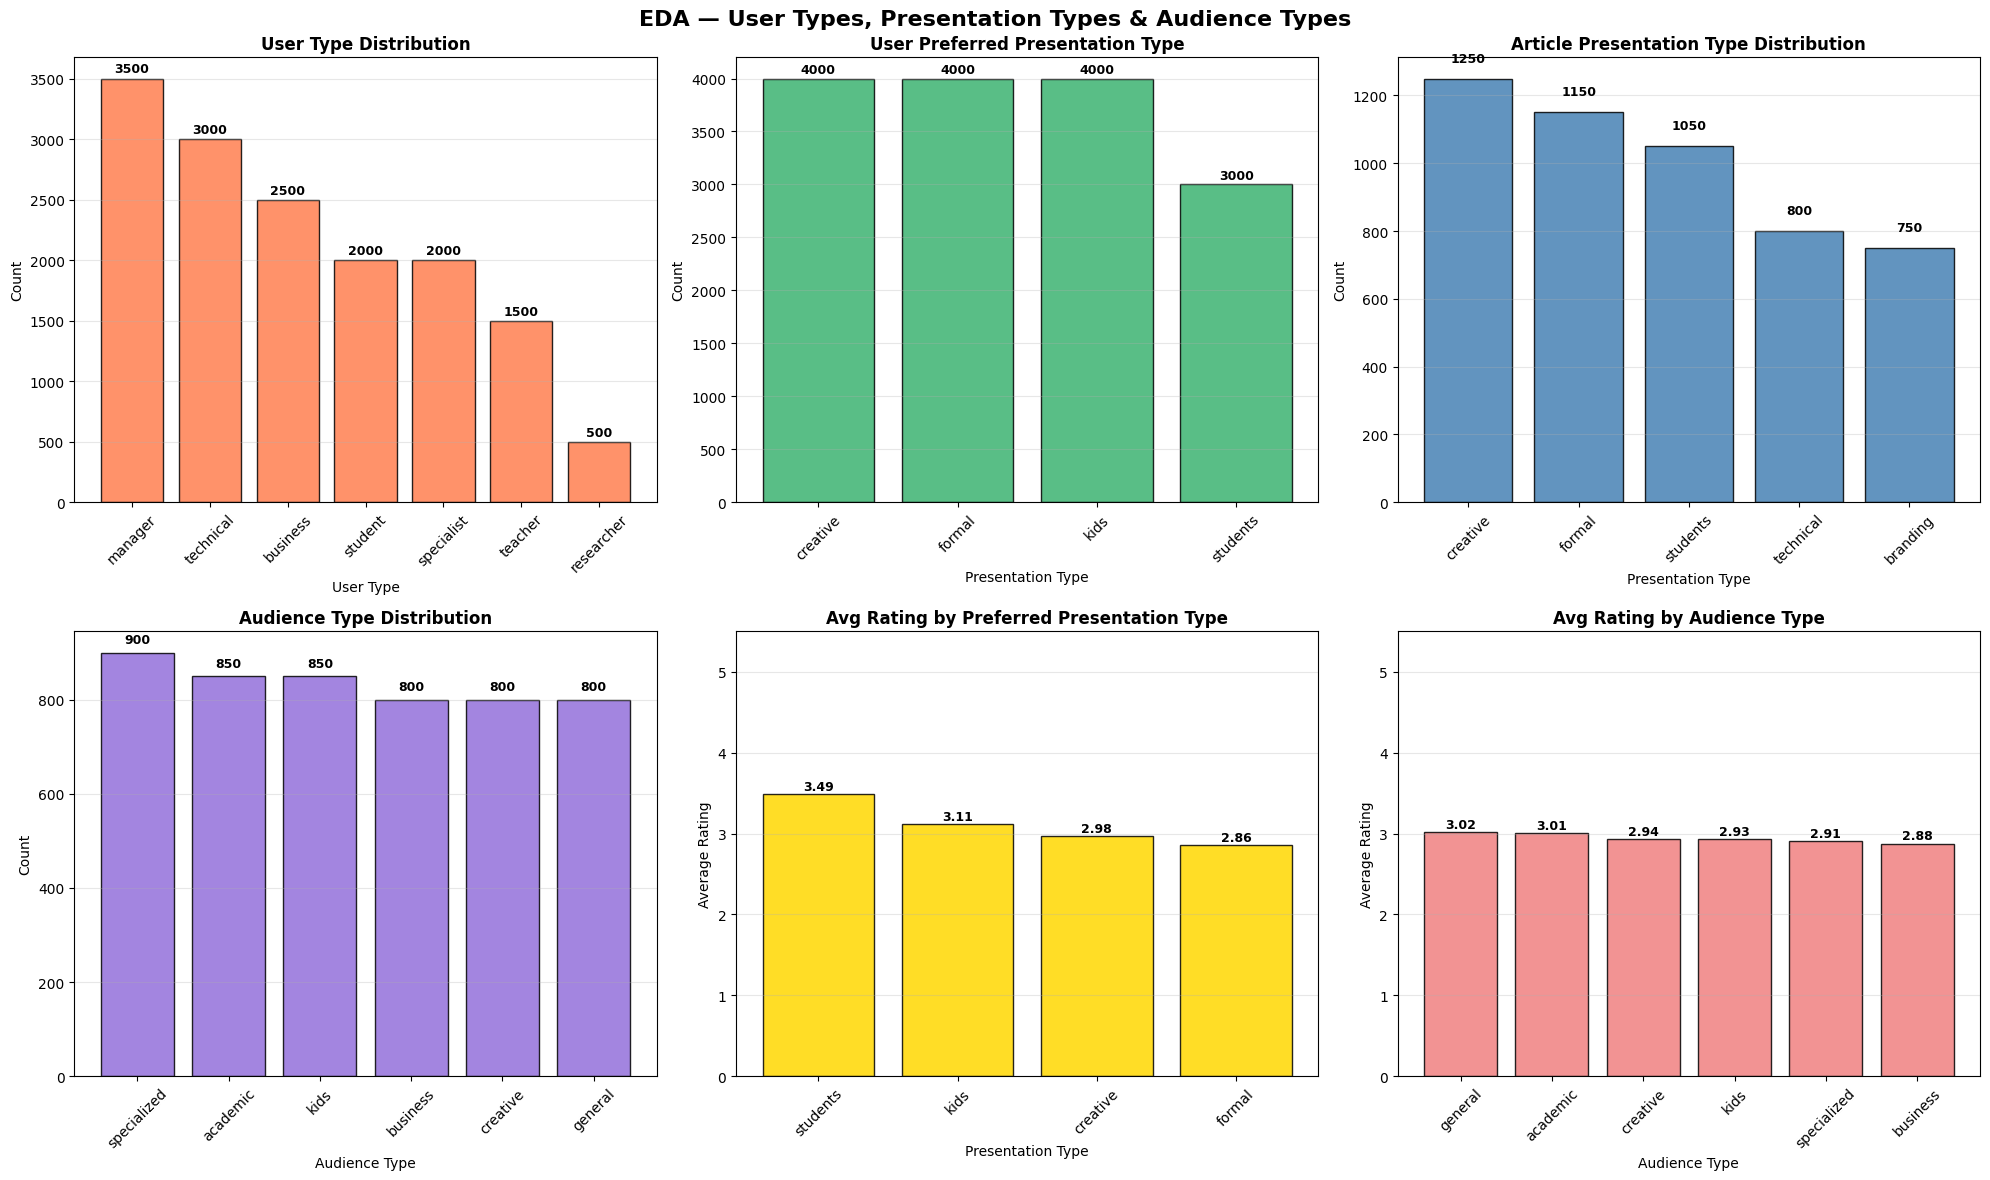


User Type Counts:
type
manager       3500
technical     3000
business      2500
student       2000
specialist    2000
teacher       1500
researcher     500

Preferred Presentation Type Counts:
preferred_presentation_type
creative    4000
formal      4000
kids        4000
students    3000

Article Presentation Type Counts:
presentation_type
creative     1250
formal       1150
students     1050
technical     800
branding      750

Audience Type Counts:
audience_type
specialized    900
academic       850
kids           850
business       800
creative       800
general        800


In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('EDA — User Types, Presentation Types & Audience Types',
             fontsize=16, fontweight='bold')

# ── Plot 1: User Types (from string column in df_merged) ─
user_type_counts = df_merged['type'].value_counts()

bars1 = axes[0,0].bar(user_type_counts.index, user_type_counts.values,
                       color='coral', edgecolor='black', alpha=0.85)
axes[0,0].set_title('User Type Distribution', fontweight='bold')
axes[0,0].set_xlabel('User Type')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, user_type_counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 2: User Preferred Presentation Type ─────────────
pref_ptype = df_merged['preferred_presentation_type'].value_counts()

bars2 = axes[0,1].bar(pref_ptype.index, pref_ptype.values,
                       color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[0,1].set_title('User Preferred Presentation Type', fontweight='bold')
axes[0,1].set_xlabel('Presentation Type')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, pref_ptype.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 3: Article Presentation Type ────────────────────
# Use the string column from recommendations merge
art_ptype = df_merged['presentation_type'].value_counts()

bars3 = axes[0,2].bar(art_ptype.index, art_ptype.values,
                       color='steelblue', edgecolor='black', alpha=0.85)
axes[0,2].set_title('Article Presentation Type Distribution', fontweight='bold')
axes[0,2].set_xlabel('Presentation Type')
axes[0,2].set_ylabel('Count')
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, art_ptype.values):
    axes[0,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 4: Audience Type Distribution ───────────────────
# Use string column, NOT one-hot columns (those are all zeros)
aud_counts = df_merged['audience_type'].value_counts()

bars4 = axes[1,0].bar(aud_counts.index, aud_counts.values,
                       color='mediumpurple', edgecolor='black', alpha=0.85)
axes[1,0].set_title('Audience Type Distribution', fontweight='bold')
axes[1,0].set_xlabel('Audience Type')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, aud_counts.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 20,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 5: Avg Rating by Preferred Presentation Type ────
avg_by_ptype = (df_merged
                .groupby('preferred_presentation_type')['rating']
                .mean()
                .sort_values(ascending=False))

bars5 = axes[1,1].bar(avg_by_ptype.index, avg_by_ptype.values,
                       color='gold', edgecolor='black', alpha=0.85)
axes[1,1].set_title('Avg Rating by Preferred Presentation Type',
                     fontweight='bold')
axes[1,1].set_xlabel('Presentation Type')
axes[1,1].set_ylabel('Average Rating')
axes[1,1].set_ylim(0, 5.5)
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars5, avg_by_ptype.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# ── Plot 6: Avg Rating by Audience Type ──────────────────
avg_by_aud = (df_merged
              .groupby('audience_type')['rating']
              .mean()
              .sort_values(ascending=False))

bars6 = axes[1,2].bar(avg_by_aud.index, avg_by_aud.values,
                       color='lightcoral', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Avg Rating by Audience Type', fontweight='bold')
axes[1,2].set_xlabel('Audience Type')
axes[1,2].set_ylabel('Average Rating')
axes[1,2].set_ylim(0, 5.5)
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars6, avg_by_aud.values):
    axes[1,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_user_presentation_types.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print the actual values ───────────────────────────────
print("\nUser Type Counts:")
print(user_type_counts.to_string())
print("\nPreferred Presentation Type Counts:")
print(pref_ptype.to_string())
print("\nArticle Presentation Type Counts:")
print(art_ptype.to_string())
print("\nAudience Type Counts:")
print(aud_counts.to_string())

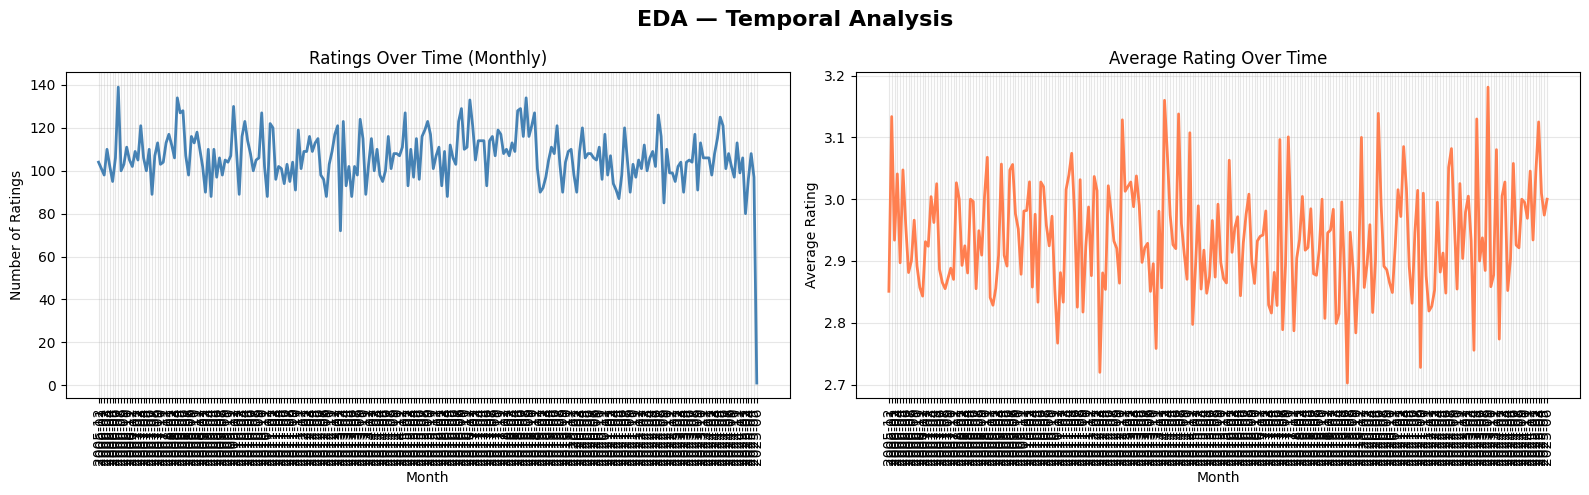

In [15]:
interaction_data['timestamp'] = pd.to_datetime(interaction_data['timestamp'])
ratings_matrix['timestamp']   = pd.to_datetime(ratings_matrix['timestamp'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('EDA — Temporal Analysis', fontsize=16, fontweight='bold')

# Ratings over time
interaction_data['year_month'] = interaction_data['timestamp'].dt.to_period('M')
monthly_counts = interaction_data.groupby('year_month').size()
axes[0].plot(monthly_counts.index.astype(str), monthly_counts.values,
             color='steelblue', linewidth=2)
axes[0].set_title('Ratings Over Time (Monthly)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Ratings')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True, alpha=0.3)

# Average rating over time
monthly_avg = interaction_data.groupby('year_month')['rating'].mean()
axes[1].plot(monthly_avg.index.astype(str), monthly_avg.values,
             color='coral', linewidth=2)
axes[1].set_title('Average Rating Over Time')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
print("Starting Feature Engineering...")

df = interaction_data.copy()

# ── 1. Timestamp features ─────────────────────────────────
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month']     = df['timestamp'].dt.month

# Cyclic encoding (matches paper's sinusoidal approach)
df['hour_sin']  = np.sin(2 * np.pi * df['hour']      / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']      / 24)
df['day_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['day_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month']     / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month']     / 12)

# Days since first interaction per user
df = df.sort_values('timestamp')
first_ts = df.groupby('user_id')['timestamp'].transform('min')
df['days_since_first'] = (df['timestamp'] - first_ts).dt.days

# ── 2. User activity features ─────────────────────────────
user_stats = df.groupby('user_id').agg(
    user_avg_rating    = ('rating', 'mean'),
    user_rating_count  = ('rating', 'count'),
    user_rating_std    = ('rating', 'std')
).reset_index()
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)
df = df.merge(user_stats, on='user_id', how='left')

# ── 3. Item activity features ─────────────────────────────
item_stats = df.groupby('article_id').agg(
    item_avg_rating   = ('rating', 'mean'),
    item_rating_count = ('rating', 'count'),
    item_rating_std   = ('rating', 'std')
).reset_index()
item_stats['item_rating_std'] = item_stats['item_rating_std'].fillna(0)
df = df.merge(item_stats, on='article_id', how='left')

# ── 4. User-item match score ──────────────────────────────
pref_cols  = [c for c in df.columns if c.startswith('user_preference_')]
issue_cols = ['Boring presentation','Graphics','Readability','Consistency',
              'Images','Bullets','Text size','Text heavy','Tables',
              'Agenda','Infographics','Positioning']

# How many issues match user preferences
def compute_match(row):
    score = 0
    for p, i in zip(pref_cols, issue_cols):
        if i in row.index:
            score += int(row[p] == row[i])
    return score

tqdm.pandas(desc="Computing match scores")
df['preference_match_score'] = df.progress_apply(compute_match, axis=1)

# ── 5. Exponential decay weight (paper's approach) ────────
decay_rate = 0.01
df['time_decay_weight'] = np.exp(-decay_rate * df['days_since_first'])

# ── 6. Normalize continuous features ─────────────────────
scaler = MinMaxScaler()
cols_to_scale = ['days_since_first','user_avg_rating','user_rating_count',
                 'user_rating_std','item_avg_rating','item_rating_count',
                 'item_rating_std','preference_match_score','time_decay_weight']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"Feature engineering done. Final shape: {df.shape}")
print(f"New columns added: {df.shape[1] - interaction_data.shape[1]}")
df.head(3)

Starting Feature Engineering...


Computing match scores: 100%|██████████| 25000/25000 [00:01<00:00, 20772.26it/s]

Feature engineering done. Final shape: (25000, 94)
New columns added: 18


,user_id,article_id,rating,timestamp,location,user_preference_Boring presentation,user_preference_Graphics,user_preference_Readability,user_preference_Consistency,user_preference_Images,...,month_cos,days_since_first,user_avg_rating,user_rating_count,user_rating_std,item_avg_rating,item_rating_count,item_rating_std,preference_match_score,time_decay_weight
0,13,114,3.0,2005-12-01 07:00:00,Florida,0,0,0,0,0,...,1.0,0.0,0.437714,0.0,0.902715,0.000000,0.0,0.086354,0.500000,1.0
1,14,474,2.5,2005-12-01 12:00:00,Illinois,0,0,0,0,0,...,1.0,0.0,0.232717,0.0,0.838889,0.960000,0.0,0.957237,0.416667,1.0
2,17,449,4.5,2005-12-01 17:00:00,Illinois,0,0,0,0,0,...,1.0,0.0,0.107118,0.0,0.980352,0.866667,0.0,0.532169,0.333333,1.0


In [17]:
print("="*60)
print("MODEL 1: CBF + CF BASELINE")
print("="*60)

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import time
from datetime import timedelta

np.random.seed(42)

# ── Use ratings_matrix as the interaction source ──────────
rm = ratings_matrix.copy()

print(f"Ratings matrix shape : {rm.shape}")
print(f"Unique users         : {rm['user_id'].nunique()}")
print(f"Unique articles      : {rm['article_id'].nunique()}")
print(f"Rating range         : {rm['rating'].min()} → {rm['rating'].max()}")

MODEL 1: CBF + CF BASELINE
Ratings matrix shape : (3000, 5)
Unique users         : 30
Unique articles      : 100
Rating range         : 2.0 → 5.0


In [18]:
# Create pivot table: rows=users, cols=articles, values=ratings
# Missing = 0 (not rated)

user_item_cf = rm.pivot_table(
    index='user_id',
    columns='article_id',
    values='rating',
    fill_value=0
)

print(f"User-Item matrix shape : {user_item_cf.shape}")
print(f"Sparsity               : {(user_item_cf == 0).sum().sum() / user_item_cf.size:.4f}")
user_item_cf.head(3)

User-Item matrix shape : (30, 100)
Sparsity               : 0.0000


article_id,1,2,3,4,5,6,7,8,9,10,...,91,92,93,94,95,96,97,98,99,100
user_id,,,,,,,,,,,,,,,,,,,,,
1,4.5,3.0,4.5,3.0,3.0,4.5,3.5,5.0,4.5,3.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,4.5,3.0
2,2.0,2.0,3.5,2.0,2.0,3.5,3.0,3.5,3.5,2.0,...,3.5,3.0,2.0,2.5,3.0,2.0,2.0,2.0,3.5,2.0
3,3.0,2.0,3.5,2.0,2.0,3.5,2.0,3.5,3.5,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,3.5,2.0


In [19]:
# Article content features from recommendations dataframe
# These are the binary issue columns + presentation/audience type

issue_cols = [
    'Boring presentation','Graphics','Readability','Consistency',
    'Images','Bullets','Text size','Text heavy','Tables','Agenda',
    'Infographics','Positioning','Presentation length','General tips',
    'Presentation skills','Powerpoint knowledge','tips and tricks',
    'Explanation of the problem'
]

# One-hot encode categorical columns
rec_features = recommendations.copy()
rec_features = rec_features.set_index('article_id')

ptype_dummies = pd.get_dummies(rec_features['presentation_type'], prefix='ptype')
atype_dummies = pd.get_dummies(rec_features['audience_type'],     prefix='atype')

article_features = pd.concat([
    rec_features[issue_cols],
    ptype_dummies,
    atype_dummies
], axis=1).fillna(0)

print(f"Article feature matrix : {article_features.shape}")
print(f"Feature columns        : {article_features.columns.tolist()}")

Article feature matrix : (100, 29)
Feature columns        : ['Boring presentation', 'Graphics', 'Readability', 'Consistency', 'Images', 'Bullets', 'Text size', 'Text heavy', 'Tables', 'Agenda', 'Infographics', 'Positioning', 'Presentation length', 'General tips', 'Presentation skills', 'Powerpoint knowledge', 'tips and tricks', 'Explanation of the problem', 'ptype_branding', 'ptype_creative', 'ptype_formal', 'ptype_students', 'ptype_technical', 'atype_academic', 'atype_business', 'atype_creative', 'atype_general', 'atype_kids', 'atype_specialized']


In [21]:
# CF similarity: user-user cosine similarity
user_sim_matrix = cosine_similarity(user_item_cf.values)
user_sim_df = pd.DataFrame(
    user_sim_matrix,
    index=user_item_cf.index,
    columns=user_item_cf.index
)

# CBF similarity: item-item cosine similarity
# Only for articles that appear in both recommendations and ratings_matrix
common_articles = list(
    set(article_features.index) & set(user_item_cf.columns)
)
article_features_filtered = article_features.loc[common_articles]

item_sim_matrix = cosine_similarity(article_features_filtered.values)
item_sim_df = pd.DataFrame(
    item_sim_matrix,
    index=common_articles,
    columns=common_articles
)

print(f"User similarity matrix : {user_sim_df.shape}")
print(f"Item similarity matrix : {item_sim_df.shape}")
print(f"Common articles        : {len(common_articles)}")

User similarity matrix : (30, 30)
Item similarity matrix : (100, 100)
Common articles        : 100


In [22]:
def predict_cf(user_id, article_id, user_item_mat, user_sim, k=10):
    """
    User-based CF prediction.
    Find top-k similar users who rated this article,
    then take their weighted average rating.
    """
    if article_id not in user_item_mat.columns:
        return user_item_mat.values[user_item_mat.values > 0].mean()

    # Similarities to all other users
    if user_id not in user_sim.index:
        return user_item_mat[article_id][user_item_mat[article_id] > 0].mean()

    sim_scores = user_sim[user_id].drop(user_id)

    # Only users who rated this article
    rated_mask = user_item_mat[article_id] > 0
    sim_scores = sim_scores[rated_mask]

    if len(sim_scores) == 0:
        col = user_item_mat[article_id]
        return col[col > 0].mean() if (col > 0).any() else 3.0

    # Top-k similar users
    top_k = sim_scores.nlargest(k)
    ratings = user_item_mat[article_id][top_k.index]

    denom = top_k.abs().sum()
    if denom == 0:
        return ratings.mean()

    return (top_k.values * ratings.values).sum() / denom


def predict_cbf(user_id, article_id, user_item_mat, item_sim, k=10):
    """
    Item-based CBF prediction.
    Find top-k similar articles that this user rated,
    then take their weighted average.
    """
    if article_id not in item_sim.index:
        return user_item_mat.values[user_item_mat.values > 0].mean()

    if user_id not in user_item_mat.index:
        return 3.0

    user_ratings = user_item_mat.loc[user_id]
    rated_articles = user_ratings[user_ratings > 0].index
    common = [a for a in rated_articles if a in item_sim.index]

    if len(common) == 0:
        return user_ratings[user_ratings > 0].mean() if (user_ratings > 0).any() else 3.0

    sim_scores = item_sim[article_id][common]
    top_k = sim_scores.nlargest(k)
    ratings = user_ratings[top_k.index]

    denom = top_k.abs().sum()
    if denom == 0:
        return ratings.mean()

    return (top_k.values * ratings.values).sum() / denom


def predict_hybrid(user_id, article_id, user_item_mat,
                   user_sim, item_sim, alpha=0.5, k=10):
    """
    Hybrid = alpha * CF + (1-alpha) * CBF
    alpha=0.5 gives equal weight
    """
    cf_pred  = predict_cf(user_id, article_id, user_item_mat, user_sim, k)
    cbf_pred = predict_cbf(user_id, article_id, user_item_mat, item_sim, k)
    return alpha * cf_pred + (1 - alpha) * cbf_pred

print("Prediction functions defined")

Prediction functions defined


In [23]:
# Split ratings_matrix 70/15/15
train_rm, temp_rm = train_test_split(rm, test_size=0.30, random_state=42)
val_rm,   test_rm = train_test_split(temp_rm, test_size=0.50, random_state=42)

# Build training user-item matrix only
train_pivot = train_rm.pivot_table(
    index='user_id',
    columns='article_id',
    values='rating',
    fill_value=0
)

# Recompute user similarity on train only
train_user_sim = pd.DataFrame(
    cosine_similarity(train_pivot.values),
    index=train_pivot.index,
    columns=train_pivot.index
)

print(f"Train : {len(train_rm)} | Val : {len(val_rm)} | Test : {len(test_rm)}")
print("Starting predictions on test set...")

start = time.time()

y_true_cbf, y_pred_cf_list  = [], []
y_pred_cbf_list, y_pred_hybrid_list = [], []

for _, row in test_rm.iterrows():
    uid = row['user_id']
    iid = row['article_id']
    true_r = row['rating']

    pred_cf     = predict_cf(uid, iid, train_pivot, train_user_sim, k=10)
    pred_cbf    = predict_cbf(uid, iid, train_pivot, item_sim_df, k=10)
    pred_hybrid = 0.5 * pred_cf + 0.5 * pred_cbf

    # Clip to rating range
    pred_cf     = np.clip(pred_cf,     2.0, 5.0)
    pred_cbf    = np.clip(pred_cbf,    2.0, 5.0)
    pred_hybrid = np.clip(pred_hybrid, 2.0, 5.0)

    y_true_cbf.append(true_r)
    y_pred_cf_list.append(pred_cf)
    y_pred_cbf_list.append(pred_cbf)
    y_pred_hybrid_list.append(pred_hybrid)

training_time = time.time() - start

y_true    = np.array(y_true_cbf)
y_pred_cf = np.array(y_pred_cf_list)
y_pred_cb = np.array(y_pred_cbf_list)
y_pred_h  = np.array(y_pred_hybrid_list)

# Metrics
def get_metrics(yt, yp):
    mae  = mean_absolute_error(yt, yp)
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    return mae, mse, rmse

mae_cf,  mse_cf,  rmse_cf  = get_metrics(y_true, y_pred_cf)
mae_cb,  mse_cb,  rmse_cb  = get_metrics(y_true, y_pred_cb)
mae_h,   mse_h,   rmse_h   = get_metrics(y_true, y_pred_h)

print("\n" + "="*65)
print("  MODEL 1: CBF + CF RESULTS")
print("="*65)
print(f"  CF only  → MAE: {mae_cf:.4f} | MSE: {mse_cf:.4f} | RMSE: {rmse_cf:.4f}")
print(f"  CBF only → MAE: {mae_cb:.4f} | MSE: {mse_cb:.4f} | RMSE: {rmse_cb:.4f}")
print(f"  Hybrid   → MAE: {mae_h:.4f} | MSE: {mse_h:.4f} | RMSE: {rmse_h:.4f}")
print(f"\n  Paper    → MAE: 1.13   | MSE: 1.96   | RMSE: 1.40")
print(f"  Time     : {str(timedelta(seconds=int(training_time)))}")
print("="*65)

Train : 2100 | Val : 450 | Test : 450
Starting predictions on test set...

  MODEL 1: CBF + CF RESULTS
  CF only  → MAE: 0.7464 | MSE: 0.8483 | RMSE: 0.9210
  CBF only → MAE: 0.3773 | MSE: 0.2224 | RMSE: 0.4716
  Hybrid   → MAE: 0.5255 | MSE: 0.3908 | RMSE: 0.6252

  Paper    → MAE: 1.13   | MSE: 1.96   | RMSE: 1.40
  Time     : 0:00:01


In [24]:
import os, json
os.makedirs('saved_models', exist_ok=True)

# Save predictions
cbf_cf_results = pd.DataFrame({
    'true_rating'    : y_true,
    'pred_cf'        : y_pred_cf,
    'pred_cbf'       : y_pred_cb,
    'pred_hybrid'    : y_pred_h
})
cbf_cf_results.to_csv('saved_models/cbf_cf_predictions.csv', index=False)

# Save metrics
metrics = {
    'model'         : 'CBF+CF',
    'MAE_hybrid'    : round(mae_h,  4),
    'MSE_hybrid'    : round(mse_h,  4),
    'RMSE_hybrid'   : round(rmse_h, 4),
    'MAE_cf_only'   : round(mae_cf, 4),
    'MAE_cbf_only'  : round(mae_cb, 4),
    'timing_seconds': round(training_time, 2),
    'paper_MAE'     : 1.13,
    'beats_paper'   : bool(mae_h < 1.13)
}
with open('saved_models/cbf_cf_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Saved:")
print("  saved_models/cbf_cf_predictions.csv")
print("  saved_models/cbf_cf_metrics.json")
print(f"\n  Beats paper? {'YES' if mae_h < 1.13 else 'NO'}")
print(f"  Paper MAE: 1.13 | Our MAE: {mae_h:.4f}")

Saved:
  saved_models/cbf_cf_predictions.csv
  saved_models/cbf_cf_metrics.json

  Beats paper? YES
  Paper MAE: 1.13 | Our MAE: 0.5255


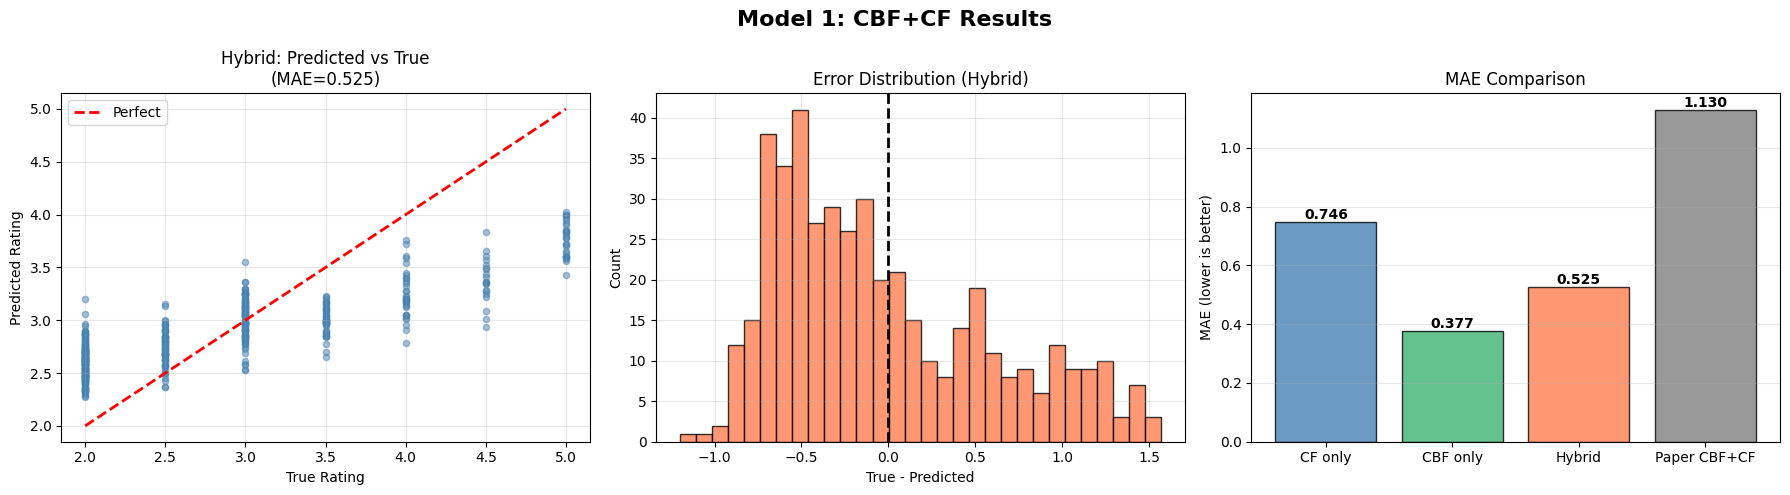

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model 1: CBF+CF Results', fontsize=16, fontweight='bold')

# Predicted vs True (hybrid)
axes[0].scatter(y_true, y_pred_h, alpha=0.5, s=20, color='steelblue')
axes[0].plot([2, 5], [2, 5], 'r--', linewidth=2, label='Perfect')
axes[0].set_title(f'Hybrid: Predicted vs True\n(MAE={mae_h:.3f})')
axes[0].set_xlabel('True Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error distribution
errors = y_true - y_pred_h
axes[1].hist(errors, bins=30, color='coral',
             edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].set_title('Error Distribution (Hybrid)')
axes[1].set_xlabel('True - Predicted')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

# Model comparison bar chart
models     = ['CF only', 'CBF only', 'Hybrid', 'Paper CBF+CF']
mae_vals   = [mae_cf, mae_cb, mae_h, 1.13]
colors     = ['steelblue', 'mediumseagreen', 'coral', 'gray']
bars = axes[2].bar(models, mae_vals, color=colors,
                   edgecolor='black', alpha=0.8)
axes[2].set_title('MAE Comparison')
axes[2].set_ylabel('MAE (lower is better)')
axes[2].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, mae_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('saved_models/cbf_cf_results.png', dpi=150, bbox_inches='tight')
plt.show()